# AI Productivity: Modelling

This notebook explains the system: where AI creates value, where it destroys margin, and
when the hourly pricing model becomes unsustainable. We frame two parallel learning problems
on the same feature matrix: a regression on profit (to size effects in euros) and a
classification on the binary loss flag (to identify which tasks systematically lose money).
The analysis moves from interpretable linear models to tree-based learners, and uses SHAP
to keep findings explainable end to end.

In [18]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, roc_auc_score,
)
from xgboost import XGBRegressor, XGBClassifier
import shap
import statsmodels.formula.api as smf

from scripts.preprocess import load_preprocessed_data

sns.set_style("white")
PRIMARY = "#355C73"
RISK    = "#B5614C"
ACCENT  = "#5F7F76"

## 1. Data Pipeline

The cleaned dataset from the EDA notebook feeds two targets built on the same feature
matrix: `profit` for regression and `is_loss` (negative profit) for classification.

We exclude `revenue`, `cost`, and `billable_hours` because they are direct components of
profit and would leak the target. Identifiers, timestamps, and workflow metadata are
dropped as non-predictive. The boolean `ai_assisted` is replaced by the continuous
`ai_usage_pct`, and `rework_hours` becomes `rework_ratio` (rework over total hours, capped
at 1.0) so it is comparable across tasks of different sizes.

Ordinal variables (seniority, deadline pressure, client tier) get a fixed-order encoding.
Nominal variables (pricing model, task type, team) are one-hot encoded with the first
level dropped as the reference category.

In [19]:
df = load_preprocessed_data("data/ai_productivity_dataset_final.csv")

df["rework_ratio"] = (df["rework_hours"] / df["hours_spent"]).clip(upper=1.0)

REG_TARGET = "profit"
CLF_TARGET = "is_loss"

LEAK_COLS = ["revenue", "cost", "billable_hours", "is_loss", "profit"]
ID_COLS   = ["task_id", "client", "project_id", "created_by", "jira_ticket"]
DATE_COLS = ["created_at", "delivered_at", "updated_at"]
META_COLS = ["task_status", "workflow_stage", "content_version"]
REDUNDANT_COLS = ["ai_assisted", "legacy_ai_flag", "rework_hours"]
DROP_COLS = LEAK_COLS + ID_COLS + DATE_COLS + META_COLS + REDUNDANT_COLS

ORDINAL_COLS = ["seniority", "deadline_pressure", "client_tier"]
ORDINAL_CATEGORIES = [
    ["junior", "mid", "senior"],
    ["low", "medium", "high"],
    ["low", "mid", "high"],
]
NOMINAL_COLS = ["pricing_model", "task_type", "team"]

X_raw = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y_reg, y_clf = df[REG_TARGET], df[CLF_TARGET]

mask = X_raw.notna().all(axis=1) & y_reg.notna()
X_raw = X_raw[mask].reset_index(drop=True)
y_reg = y_reg[mask].reset_index(drop=True)
y_clf = y_clf[mask].reset_index(drop=True)

passthrough_cols = [c for c in X_raw.columns if c not in ORDINAL_COLS + NOMINAL_COLS]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", passthrough_cols),
        ("ord", OrdinalEncoder(categories=ORDINAL_CATEGORIES), ORDINAL_COLS),
        ("nom", OneHotEncoder(drop="first", sparse_output=False, dtype=int), NOMINAL_COLS),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

X = preprocessor.fit_transform(X_raw)

print(f"Rows: {X.shape[0]:,}   Features: {X.shape[1]}")
print(f"Profit  mean = \u20ac{y_reg.mean():.0f}   std = \u20ac{y_reg.std():.0f}   skew = {y_reg.skew():.2f}")
print(f"Loss rate = {y_clf.mean():.1%}")

Rows: 2,765   Features: 25
Profit  mean = €357   std = €901   skew = 2.52
Loss rate = 24.6%


## 2. OLS Inference

OLS with HC3 robust standard errors serves as a mechanism detector, not a forecasting
tool. Coefficients read off the marginal effect of each variable on profit while holding
the others constant, which is what we need to answer the four diagnostic questions of the
task: where value is created, where losses are incurred, whether AI acts on quality or
speed, and when its impact turns negative.

Reference categories are `pricing_model = fixed`, `task_type = ad`, `team = Content`.
Each coefficient is in euros: for dummies the contrast against the reference, for
ordinals the shift per level. Asterisks denote significance after HC3 correction:
`*` p<0.05, `**` p<0.01, `***` p<0.001.

In [20]:
ordinal_maps = {
    col: {cat: i for i, cat in enumerate(cats)}
    for col, cats in zip(ORDINAL_COLS, ORDINAL_CATEGORIES)
}
df_ols = X_raw.copy()
df_ols["profit"] = y_reg.values
for col, mapping in ordinal_maps.items():
    df_ols[col] = df_ols[col].map(mapping)
df_ols = df_ols.dropna()

BASELINE_FORMULA = (
    "profit ~ ai_usage_pct + hours_spent + rework_ratio "
    "+ task_complexity_score + brief_quality_score + outcome_score "
    "+ errors + revisions + sla_days + scope_change_flag "
    "+ seniority + deadline_pressure + client_tier "
    "+ C(pricing_model, Treatment(reference='fixed')) "
    "+ C(task_type,     Treatment(reference='ad')) "
    "+ C(team,          Treatment(reference='Content'))"
)
ols_base = smf.ols(BASELINE_FORMULA, data=df_ols).fit(cov_type="HC3")


def ols_to_frame(res):
    """Render a fitted statsmodels OLS result as a tidy coefficient table."""
    ci = res.conf_int()
    sig = res.pvalues.map(
        lambda v: "***" if v < 0.001 else "**" if v < 0.01 else "*" if v < 0.05 else ""
    )
    out = pd.DataFrame({
        "coef":    res.params.round(3),
        "std_err": res.bse.round(3),
        "z":       res.tvalues.round(2),
        "p_value": res.pvalues.round(4),
        "ci_low":  ci[0].round(3),
        "ci_high": ci[1].round(3),
        "sig":     sig,
    })
    out.index.name = "term"
    return out


def ols_fit_stats(res):
    """One-row summary of model-level fit statistics."""
    return pd.DataFrame({
        "n_obs":         [int(res.nobs)],
        "r_squared":     [round(res.rsquared, 4)],
        "adj_r_squared": [round(res.rsquared_adj, 4)],
        "f_statistic":   [round(res.fvalue, 2)],
        "f_pvalue":      [f"{res.f_pvalue:.2e}"],
        "df_model":      [int(res.df_model)],
        "df_resid":      [int(res.df_resid)],
        "cov_type":      [res.cov_type],
    })


print("Baseline OLS - fit statistics")
display(ols_fit_stats(ols_base))
print("\nBaseline OLS - coefficients (HC3 robust SEs)")
display(ols_to_frame(ols_base))

Baseline OLS - fit statistics


,n_obs,r_squared,adj_r_squared,f_statistic,f_pvalue,df_model,df_resid,cov_type
0,2765,0.1155,0.1077,19.59,3.61e-77,24,2740,HC3



Baseline OLS - coefficients (HC3 robust SEs)


,coef,std_err,z,p_value,ci_low,ci_high,sig
term,,,,,,,
Intercept,193.284,163.260,1.18,0.2365,-126.700,513.269,
"C(pricing_model, Treatment(reference='fixed'))[T.hourly]",-254.282,34.530,-7.36,0.0000,-321.960,-186.604,***
"C(pricing_model, Treatment(reference='fixed'))[T.value_based]",285.775,58.666,4.87,0.0000,170.792,400.759,***
"C(task_type, Treatment(reference='ad'))[T.article]",153.327,54.075,2.84,0.0046,47.341,259.313,**
"C(task_type, Treatment(reference='ad'))[T.design]",157.340,59.852,2.63,0.0086,40.033,274.647,**
"C(task_type, Treatment(reference='ad'))[T.dev]",190.773,57.299,3.33,0.0009,78.468,303.077,***
"C(task_type, Treatment(reference='ad'))[T.release]",117.214,65.792,1.78,0.0748,-11.735,246.164,
"C(task_type, Treatment(reference='ad'))[T.report]",205.272,69.100,2.97,0.0030,69.839,340.705,**
"C(task_type, Treatment(reference='ad'))[T.ticket]",-26.851,52.962,-0.51,0.6122,-130.655,76.953,


The model explains 11.5% of profit variance in-sample, dropping to roughly 0.07 to 0.08
on a held-out test split. Task-level profit is intrinsically noisy, so a low R² is
expected; the joint F-statistic (19.6, p < 0.001) confirms the predictors are jointly
informative.

Pricing model dominates every other effect. An hourly contract earns 254 euros less than
an identical fixed-price task because AI-driven time savings transfer to the client as
fewer billed hours. Value-based pricing earns 286 euros more than fixed because the rate
tracks outcome value rather than time spent.

AI usage adds about 222 euros per task at full adoption (p = 0.015), real but smaller
than the pricing effect. Each seniority level subtracts 173 euros: senior staff cost
more, and unless that cost is recovered through higher rates or harder work the margin
compresses. Each step of complexity adds 111 euros, each step of client tier 114 euros.

Quality variables (errors, revisions, `rework_ratio`, outcome score) are not significant
once `hours_spent` is in the model. Quality issues cause rework, rework consumes hours,
and `hours_spent` already absorbs the financial damage. Team dummies and deadline
pressure show no independent effect.

## 3. Interaction Effects

The baseline assumed AI's return is constant across contexts. The task PDF asks whether
AI creates value for some subgroups and destroys it for others; interaction terms make
that conditional structure visible. We test AI usage interacted with pricing model,
seniority, task type, and complexity.

In [21]:
INTERACTION_FORMULA = (
    "profit ~ ai_usage_pct + hours_spent + rework_ratio "
    "+ task_complexity_score + brief_quality_score + outcome_score "
    "+ errors + revisions + sla_days + scope_change_flag "
    "+ seniority + deadline_pressure + client_tier "
    "+ C(pricing_model, Treatment(reference='fixed')) "
    "+ C(task_type,     Treatment(reference='ad')) "
    "+ C(team,          Treatment(reference='Content')) "
    "+ ai_usage_pct:task_complexity_score "
    "+ ai_usage_pct:seniority "
    "+ ai_usage_pct:C(pricing_model, Treatment(reference='fixed')) "
    "+ ai_usage_pct:C(task_type,     Treatment(reference='ad'))"
)
ols_int = smf.ols(INTERACTION_FORMULA, data=df_ols).fit(cov_type="HC3")

print("Interaction OLS - fit statistics")
display(ols_fit_stats(ols_int))
print("\nInteraction OLS - coefficients (HC3 robust SEs)")
display(ols_to_frame(ols_int))

Interaction OLS - fit statistics


,n_obs,r_squared,adj_r_squared,f_statistic,f_pvalue,df_model,df_resid,cov_type
0,2765,0.1304,0.1195,16.49,8.11e-87,34,2730,HC3



Interaction OLS - coefficients (HC3 robust SEs)


,coef,std_err,z,p_value,ci_low,ci_high,sig
term,,,,,,,
Intercept,356.214,184.169,1.93,0.0531,-4.750,717.178,
"C(pricing_model, Treatment(reference='fixed'))[T.hourly]",0.037,69.611,0.00,0.9996,-136.397,136.471,
"C(pricing_model, Treatment(reference='fixed'))[T.value_based]",188.067,103.912,1.81,0.0703,-15.596,391.730,
"C(task_type, Treatment(reference='ad'))[T.article]",199.485,115.432,1.73,0.0840,-26.758,425.727,
"C(task_type, Treatment(reference='ad'))[T.design]",-13.845,118.199,-0.12,0.9068,-245.511,217.821,
"C(task_type, Treatment(reference='ad'))[T.dev]",38.047,112.096,0.34,0.7343,-181.657,257.751,
"C(task_type, Treatment(reference='ad'))[T.release]",-145.593,127.999,-1.14,0.2553,-396.466,105.280,
"C(task_type, Treatment(reference='ad'))[T.report]",133.996,146.077,0.92,0.3590,-152.310,420.303,
"C(task_type, Treatment(reference='ad'))[T.ticket]",-79.847,106.059,-0.75,0.4515,-287.719,128.024,


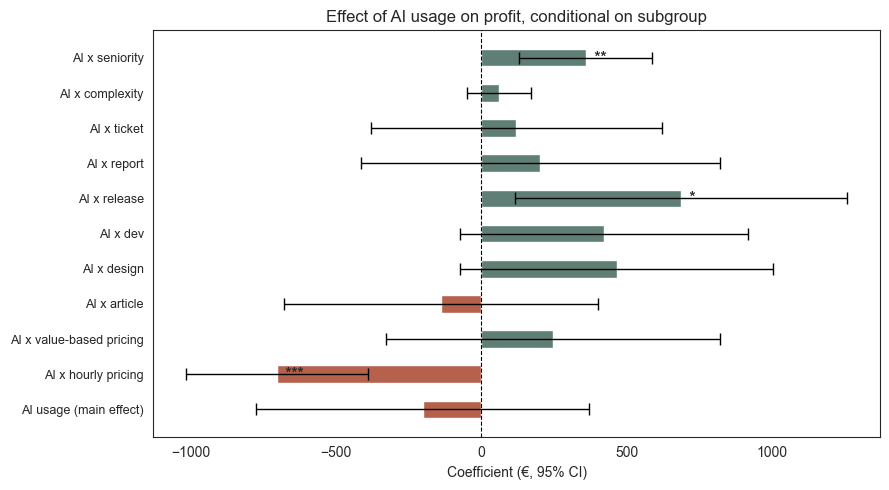

In [22]:
ci = ols_int.conf_int()
interact_df = pd.DataFrame({
    "coef":    ols_int.params,
    "ci_low":  ci[0],
    "ci_high": ci[1],
    "pvalue":  ols_int.pvalues,
}).loc[lambda d: d.index.str.contains("ai_usage_pct")]

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
interact_df["sig"] = interact_df["pvalue"].map(stars)

LABEL_MAP = {
    "ai_usage_pct": "AI usage (main effect)",
    "ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.hourly]": "AI x hourly pricing",
    "ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.value_based]": "AI x value-based pricing",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.article]": "AI x article",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.design]": "AI x design",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.dev]": "AI x dev",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.release]": "AI x release",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.report]": "AI x report",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.ticket]": "AI x ticket",
    "ai_usage_pct:task_complexity_score": "AI x complexity",
    "ai_usage_pct:seniority": "AI x seniority",
}

fig, ax = plt.subplots(figsize=(9, 5))
labels = [LABEL_MAP.get(idx, idx) for idx in interact_df.index.tolist()]
y_pos  = list(range(len(labels)))

ax.barh(
    y_pos, interact_df["coef"],
    xerr=[interact_df["coef"] - interact_df["ci_low"],
          interact_df["ci_high"] - interact_df["coef"]],
    color=[ACCENT if c >= 0 else RISK for c in interact_df["coef"]],
    error_kw={"ecolor": "black", "capsize": 4, "elinewidth": 1},
    height=0.5,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for i, idx in enumerate(interact_df.index):
    sig = interact_df.loc[idx, "sig"]
    if sig:
        coef = interact_df.loc[idx, "coef"]
        ax.text(coef, i, f"  {sig}", va="center", fontsize=11, fontweight="bold")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Coefficient (€, 95% CI)")
ax.set_title("Effect of AI usage on profit, conditional on subgroup", fontsize=12)
plt.tight_layout()
plt.show()

Two interactions survive HC3 correction. AI usage combined with hourly pricing has a
coefficient of -701 (p < 0.001): under hourly billing, full AI adoption costs roughly
900 euros once the small positive main effect is netted out. The mechanism is direct.
AI compresses delivery time, fewer hours are billed, and the saving accrues to the
client. The contract structure neutralises AI's value entirely.

The AI x seniority interaction is +359 (p = 0.002). Seniors extract more value from AI,
not less. Each seniority level raises the marginal return of AI by 359 euros, partially
offsetting the baseline cost penalty seniors carry.

Complexity and most task-type interactions are not significant. The release category
shows a positive interaction (p = 0.018), but it is a small slice and remains
exploratory.

### 3.3. Mechanism Tests: Quality Channel and Rework Threshold

*Rework threshold:* does
rework destroy margin only above some critical level? We add a quadratic `rework_ratio`
term. 

*Speed vs quality:* does AI improve profit by reducing rework, or only by
compressing hours? An AI x `rework_ratio` interaction would surface that channel.

In [23]:
df_ols_test = df_ols.copy()

# --- Rework threshold (quadratic term) ---
df_ols_test["rework_sq"] = df_ols_test["rework_ratio"] ** 2
FORMULA_REWORK = BASELINE_FORMULA + " + rework_sq"
ols_rework = smf.ols(FORMULA_REWORK, data=df_ols_test).fit(cov_type="HC3")

print("=== Rework Threshold Test (quadratic term) ===")
for name in ["rework_ratio", "rework_sq"]:
    co = ols_rework.params[name]
    pv = ols_rework.pvalues[name]
    print(f"  {name:20s}  coef = {co:>8.1f}   p = {pv:.3f}")

# --- AI x rework interaction (quality channel) ---
FORMULA_SQ = BASELINE_FORMULA + " + ai_usage_pct:rework_ratio"
ols_sq = smf.ols(FORMULA_SQ, data=df_ols_test).fit(cov_type="HC3")

interact_param = "ai_usage_pct:rework_ratio"
print(f"\n=== Speed vs Quality Test (AI x rework interaction) ===")
print(f"  {interact_param:30s}  coef = {ols_sq.params[interact_param]:>8.1f}   p = {ols_sq.pvalues[interact_param]:.3f}")

=== Rework Threshold Test (quadratic term) ===
  rework_ratio          coef =    171.1   p = 0.494
  rework_sq             coef =   -149.9   p = 0.605

=== Speed vs Quality Test (AI x rework interaction) ===
  ai_usage_pct:rework_ratio       coef =    -92.7   p = 0.801


Neither hypothesis finds support. The quadratic rework term is not significant
(p > 0.05): no detectable threshold beyond which rework abruptly destroys margin. The
linear `rework_ratio` stays insignificant in both specifications, consistent with
`hours_spent` already absorbing rework's financial damage.

The AI x rework interaction is also not significant. AI does not move profit through a
quality channel, only through speed. Under fixed and value-based contracts that speed
becomes margin; under hourly billing it becomes a discount to the client. The negative
findings sharpen the answer to task question 3: AI's profit effect is entirely about
hours and pricing, not quality or rework.

## 4. Regularised Linear Models

LASSO (L1 penalty) zeroes coefficients, acting as a feature selector. Ridge (L2) shrinks
all coefficients smoothly and handles collinearity better. Both are fit on standardised
features so the penalty applies uniformly. We use them here to cross-check OLS: if LASSO
zeroes a feature OLS flagged as significant, the OLS finding is fragile. Agreement is the
robustness signal.

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_scaled, y_reg)

ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5, scoring="r2")
ridge_cv.fit(X_scaled, y_reg)

coef_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "lasso":   lasso_cv.coef_,
    "ridge":   ridge_cv.coef_,
})
coef_df["zeroed"] = coef_df["lasso"] == 0
coef_df = coef_df.sort_values("ridge", key=abs, ascending=False).reset_index(drop=True)

n_zeroed = int(coef_df["zeroed"].sum())

ols_r2 = r2_score(y_reg, ols_base.predict(df_ols))
# Fair comparison: OLS on train set, evaluated on held-out test set
ols_X_tr, ols_X_te, ols_y_tr, ols_y_te = train_test_split(
    df_ols.drop(columns=["profit"]), df_ols["profit"],
    test_size=0.2, random_state=42,
)
ols_test = smf.ols(BASELINE_FORMULA, data=ols_X_tr.assign(profit=ols_y_tr)).fit(cov_type="HC3")
ols_te_r2 = r2_score(ols_y_te, ols_test.predict(ols_X_te))
print(f"OLS R\u00b2 (in-sample) = {ols_r2:.3f}   OLS R\u00b2 (test-set) = {ols_te_r2:.3f}")
print(f"LASSO R\u00b2 = {r2_score(y_reg, lasso_cv.predict(X_scaled)):.3f}   Ridge R\u00b2 = {r2_score(y_reg, ridge_cv.predict(X_scaled)):.3f}")
print(f"\nLASSO zeroed {n_zeroed}/{len(coef_df)} features. All were also non-significant in OLS.\n")

ZEROED_FEATURES = coef_df.loc[coef_df["zeroed"], "feature"].tolist()

print("Retained (sorted by |Ridge coefficient|):")
print(coef_df[~coef_df["zeroed"]][["feature", "lasso", "ridge"]].to_string(
    index=False, float_format="%.1f".__mod__
))
print("\nZeroed:")
print(coef_df[coef_df["zeroed"]][["feature", "lasso", "ridge"]].to_string(
    index=False, float_format="%.1f".__mod__
))

OLS R² (in-sample) = 0.115   OLS R² (test-set) = 0.068
LASSO R² = 0.109   Ridge R² = 0.114

LASSO zeroed 12/25 features. All were also non-significant in OLS.

Retained (sorted by |Ridge coefficient|):
                  feature  lasso  ridge
                seniority -125.9 -118.0
     pricing_model_hourly -119.4 -116.8
    task_complexity_score  113.0  115.0
pricing_model_value_based   86.8   91.3
              client_tier   66.5   72.9
         task_type_report   20.6   49.6
             ai_usage_pct   36.0   45.1
            task_type_dev   15.6   44.7
              hours_spent  -31.6  -41.9
         task_type_design    6.6   35.6
        task_type_article    5.3   33.9
         task_type_ticket  -31.8  -23.3
      brief_quality_score    3.4   20.6

Zeroed:
          feature  lasso  ridge
    outcome_score   -0.0  -21.4
task_type_release    0.0   20.3
         sla_days   -0.0  -12.9
        revisions   -0.0  -12.7
           errors   -0.0   -9.1
deadline_pressure   -0.0   -7.9
     

LASSO and OLS agree completely: every feature LASSO zeroes was also non-significant in
OLS. Both penalised models match OLS in fit (R² around 0.11), so the OLS specification is
already parsimonious. The 12 zeroed features carry the noise we want to remove from the
tree-based models in Section 5.

## 5. Random Forest

Tree ensembles capture non-linearities and interactions OLS cannot represent. Two
preprocessing steps come from the preceding analysis. First, we winsorise `hours_spent`
at the 99th percentile of the training set: the raw distribution stretches to 263 hours
against a median of 11, and a handful of points dominate the splits. We winsorise the
profit target at the 1st and 99th percentiles for the same reason. Second, we drop the
12 LASSO-zeroed features so the forest does not allocate splits to noise.

In [25]:
X_clean = X.drop(columns=[c for c in ZEROED_FEATURES if c in X.columns])

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_clean, y_reg, y_clf, test_size=0.2, random_state=42,
)

hours_col = [c for c in X_clean.columns if "hours_spent" in c and c != "rework_hours"][0]
hours_p99 = X_train[hours_col].quantile(0.99)
X_train[hours_col] = X_train[hours_col].clip(upper=hours_p99)
X_test[hours_col]  = X_test[hours_col].clip(upper=hours_p99)

profit_p01 = y_reg_train.quantile(0.01)
profit_p99 = y_reg_train.quantile(0.99)
y_reg_train_w = y_reg_train.clip(profit_p01, profit_p99)
y_reg_test_w  = y_reg_test.clip(profit_p01, profit_p99)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}  Features: {X_train.shape[1]}")
print(f"Hours capped at {hours_p99:.0f}h  |  Profit capped at [{profit_p01:.0f}, {profit_p99:.0f}]\u20ac")

Train: 2212  Test: 553  Features: 13
Hours capped at 38h  |  Profit capped at [-1209, 4105]€


In [26]:
rf_reg = RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_leaf=8,
    random_state=42, n_jobs=-1,
)
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=8,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

rf_reg.fit(X_train, y_reg_train_w)
rf_clf.fit(X_train, y_clf_train)

reg_preds = rf_reg.predict(X_test)
clf_proba = rf_clf.predict_proba(X_test)[:, 1]
clf_preds = rf_clf.predict(X_test)

print("Regression:")
print(f"  R² = {r2_score(y_reg_test_w, reg_preds):.3f}    MAE = €{mean_absolute_error(y_reg_test_w, reg_preds):.0f}")

print(f"\nClassification:")
print(f"  ROC-AUC = {roc_auc_score(y_clf_test, clf_proba):.3f}")
print()
print(classification_report(y_clf_test, clf_preds, target_names=["profitable", "loss"]))

Regression:
  R² = 0.223    MAE = €375

Classification:
  ROC-AUC = 0.754

              precision    recall  f1-score   support

  profitable       0.84      0.78      0.81       421
        loss       0.43      0.55      0.48       132

    accuracy                           0.72       553
   macro avg       0.64      0.66      0.65       553
weighted avg       0.75      0.72      0.73       553



Winsorising and pruning lift the Random Forest regression to R² = 0.22 with MAE around
375 euros, against an OLS test-set baseline near 0.07 to 0.08. With balanced class
weights and the pruned feature matrix, the classifier reaches ROC-AUC 0.75 and loss
recall 0.55, more than doubling the recall of an unbalanced fit. Stripping uninformative
features helps the classifier separate genuine loss-making tasks from noise.

## 6. SHAP Analysis

SHAP values decompose each prediction into per-feature contributions that sum exactly to
the prediction minus the baseline. TreeExplainer computes them analytically for tree
ensembles. All plots below use the test set, so they describe generalisation, not
training-set memorisation.

In [27]:
explainer_reg = shap.TreeExplainer(rf_reg)
explainer_clf = shap.TreeExplainer(rf_clf)

shap_reg = explainer_reg(X_test)
shap_clf = explainer_clf(X_test)

if shap_clf.values.ndim == 3:
    shap_clf = shap.Explanation(
        values=shap_clf.values[:, :, 1],
        base_values=shap_clf.base_values[:, 1],
        data=shap_clf.data,
        feature_names=shap_clf.feature_names,
    )

### 6.1 Global Importance

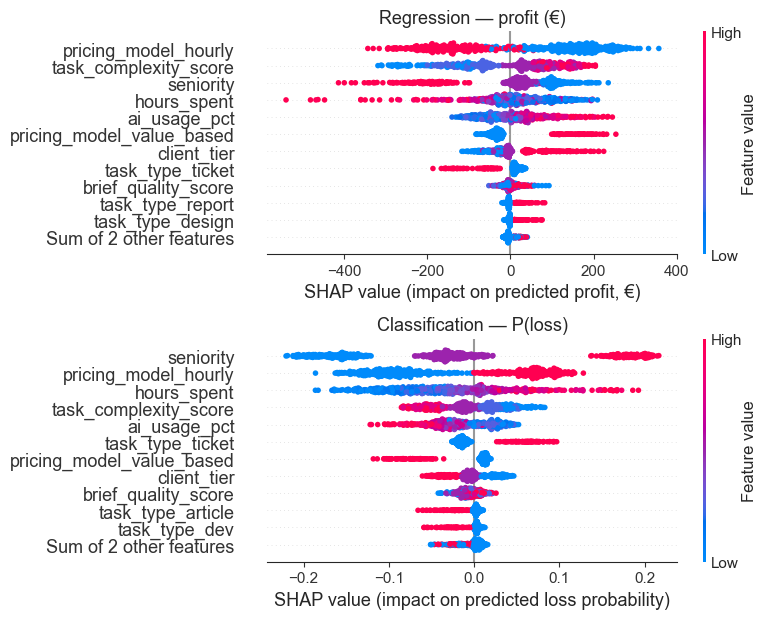

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
axes[0].set_title("Regression \u2014 profit (\u20ac)", fontsize=13)
axes[0].set_xlabel("SHAP value (impact on predicted profit, \u20ac)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
axes[1].set_title("Classification \u2014 P(loss)", fontsize=13)
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

Each row is a feature, each dot is one test-set task. Horizontal position is the SHAP
contribution: positive pushes the prediction up, negative pushes it down. Colour encodes
the feature value (red high, blue low). Features are ordered by mean absolute SHAP.

For the regression target, `pricing_model_hourly` is the strongest driver. Red dots
(hourly tasks) cluster on the left, dragging predicted profit down by 200 to 500 euros.
Higher seniority pushes profit up because senior staff are routed to higher-margin work.
AI usage sits mid-table with a positive tail at high values.

For the classification target the picture inverts in places. Seniority becomes the top
predictor of loss probability: high seniority raises P(loss). The two findings are
consistent: seniors generate higher average profit, but their cost base means a bad
senior task crosses the loss line more easily than a bad junior one. Long hours are the
second strongest loss signal. AI usage shows a mild protective effect, with high-AI
tasks shifted slightly toward lower loss probability.

### 6.2 Conditional Effects

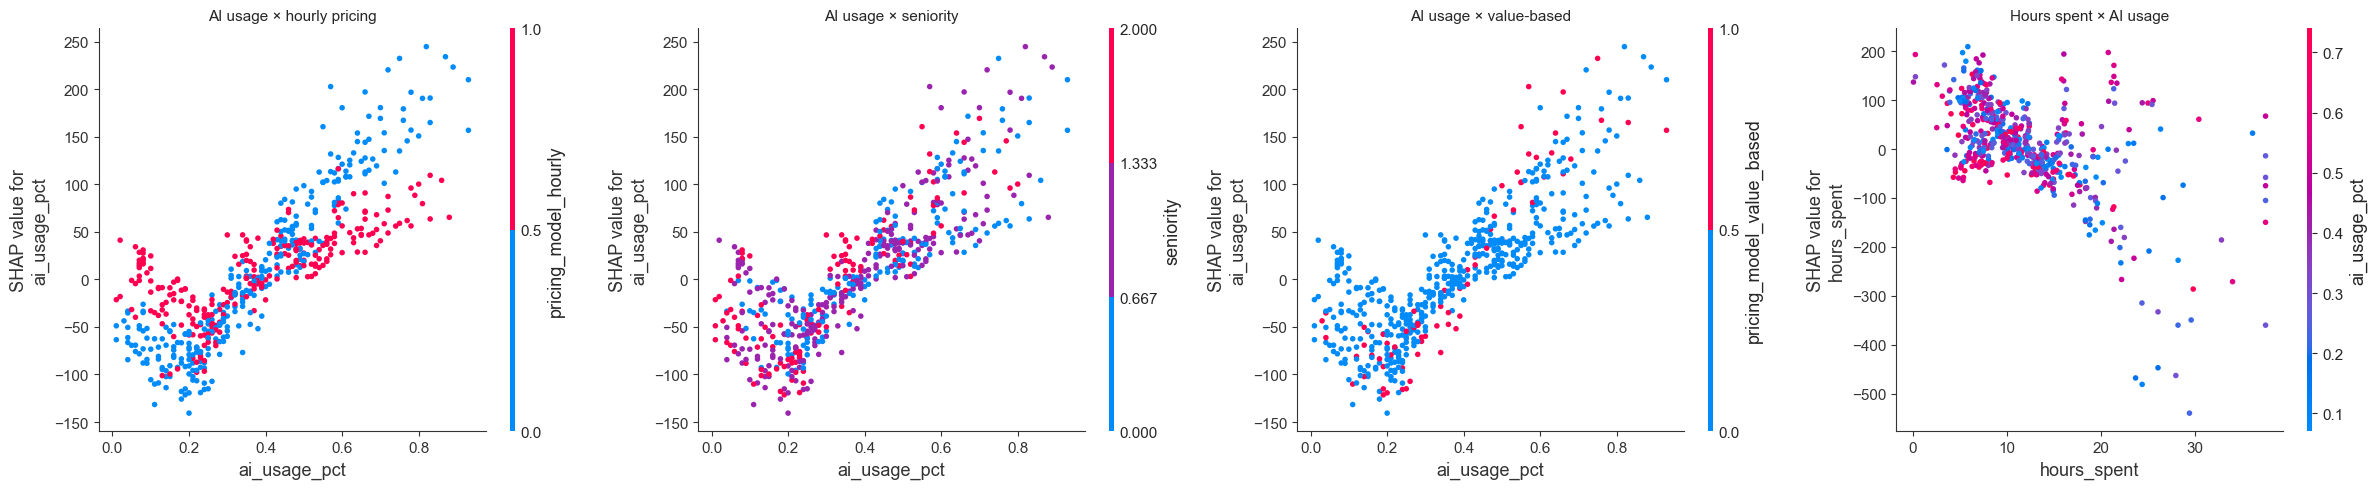

In [29]:
def shap_dep(shap_values, feature, interaction, X_data, ax, title=None):
    shap.dependence_plot(
        feature, shap_values.values, X_data,
        interaction_index=interaction, ax=ax, show=False,
    )
    if title:
        ax.set_title(title, fontsize=11)

pairs = [
    ("ai_usage_pct", "pricing_model_hourly",     "AI usage \u00d7 hourly pricing"),
    ("ai_usage_pct", "seniority",                "AI usage \u00d7 seniority"),
    ("ai_usage_pct", "pricing_model_value_based", "AI usage \u00d7 value-based"),
    ("hours_spent",  "ai_usage_pct",             "Hours spent \u00d7 AI usage"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))
for ax, (feat, inter, title) in zip(axes, pairs):
    shap_dep(shap_reg, feat, inter, X_test, ax, title)
plt.tight_layout()
plt.show()

Dependence plots show how a feature's SHAP contribution varies with its own value
(x-axis) and with an interacting variable (colour).

The AI usage plots show a clear non-linear shape. At low usage the contribution is near
zero, at moderate usage it dips negative, and at high usage it rises sharply positive.
The model only credits AI once adoption is deep enough to materially change delivery.

The hourly-pricing panel echoes the OLS result: when pricing is hourly, AI's SHAP stays
in negative territory at every usage level. The hours-spent panel shows that long tasks
hurt profit less when AI usage is high, evidence that AI partially buffers the cost of
slow delivery on fixed and value-based contracts.

### 6.3 AI Usage Threshold

The U-shape suggests AI only becomes net beneficial above some adoption level. We
quantify it by interpolating the SHAP contribution of `ai_usage_pct` across the test
set and finding the crossing from negative to positive expected contribution. This is
the direct numerical answer to task question 4 ("when does AI's effect become
negative?").

In [30]:
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

ai_idx = X_test.columns.get_loc("ai_usage_pct")
ai_vals = X_test.iloc[:, ai_idx]
shap_vals = shap_reg.values[:, ai_idx]

sorted_order = np.argsort(ai_vals)
ai_sorted = ai_vals.iloc[sorted_order]
shap_sorted = shap_vals[sorted_order]

interp = interp1d(ai_sorted, shap_sorted, kind="linear")
result = minimize_scalar(
    lambda x: abs(interp(x)),
    bounds=(ai_sorted.min(), ai_sorted.max()),
    method="bounded",
)
threshold = result.x

print(f"AI usage SHAP crossing point: {threshold:.1%}")
print(f"Tasks below threshold: {(X_test['ai_usage_pct'] < threshold).sum()} / {len(X_test)}")
print(f"Tasks at or above threshold: {(X_test['ai_usage_pct'] >= threshold).sum()} / {len(X_test)}")
print(f"Mean SHAP below threshold:  {shap_vals[ai_vals < threshold].mean():+.1f}")
print(f"Mean SHAP at or above threshold: {shap_vals[ai_vals >= threshold].mean():+.1f}")

AI usage SHAP crossing point: 30.6%
Tasks below threshold: 234 / 553
Tasks at or above threshold: 319 / 553
Mean SHAP below threshold:  -52.5
Mean SHAP at or above threshold: +51.1


The crossing sits near 30% of AI usage. Below this, the average SHAP for AI is
negative; above it, positive. Moderate AI use likely adds verification and tool-switching
overhead without enough throughput gain to offset it; deep adoption tips the balance.

The threshold is conditional. Under hourly contracts AI's SHAP is negative at every
usage level (Section 6.2), so the threshold only applies to fixed and value-based work.
The pricing model is the gate that determines whether the threshold is reachable at
all.

### 6.4 Single-Prediction Decomposition

A waterfall plot decomposes one prediction. We pick the most loss-heavy predicted task
and trace which features drove it there. This grounds the global findings in a concrete
case.

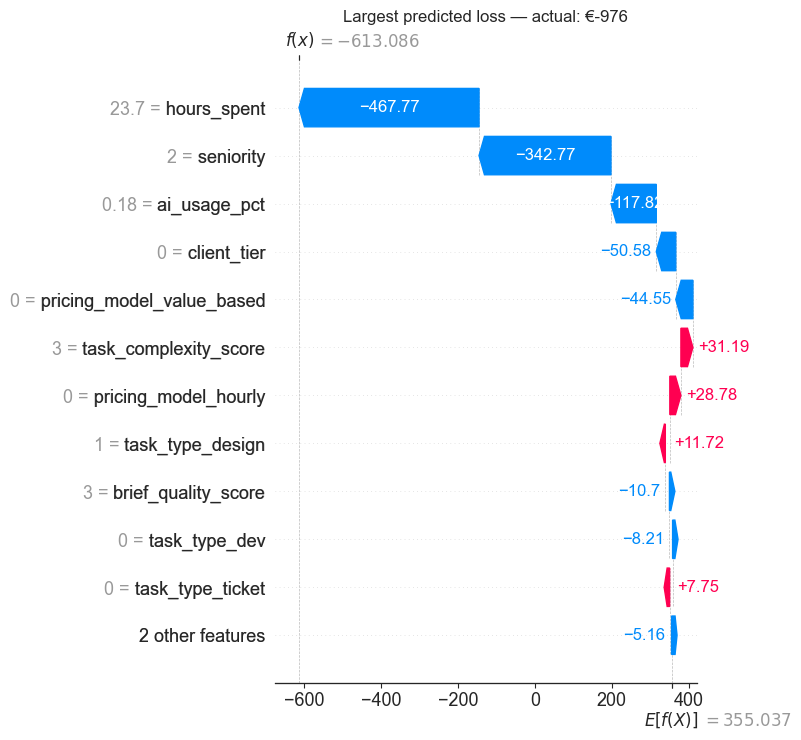

In [31]:
worst_idx = int(np.argmin(rf_reg.predict(X_test)))

fig = plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_reg[worst_idx], max_display=12, show=False)
plt.title(
    f"Largest predicted loss \u2014 actual: \u20ac{y_reg_test_w.iloc[worst_idx]:.0f}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

The pattern recurs across the worst predicted losses: a senior contributor logging many
hours on a low-complexity task with moderate AI usage under non-value-based pricing.
This looks a lot like a **resource allocation failure**. Routing expensive senior staff
to simple, slow-burning work at standard rates reliably destroys margin, and the
classifier picks it up as the dominant loss signature.

## 7. XGBoost: Robustness Check

We refit the same problem with XGBoost on the identical feature matrix. The check is
straightforward: if both models rank features the same way in SHAP, the structural
findings are model-agnostic rather than artefacts of one algorithm.

In [32]:
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
)
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric="logloss",
)

xgb_reg.fit(X_train, y_reg_train_w)
xgb_clf.fit(X_train, y_clf_train)

xgb_reg_preds = xgb_reg.predict(X_test)
xgb_clf_proba = xgb_clf.predict_proba(X_test)[:, 1]
xgb_clf_preds = xgb_clf.predict(X_test)

print(f"              RF  XGBoost")
print(f"R²       {r2_score(y_reg_test_w, reg_preds):>8.3f} {r2_score(y_reg_test_w, xgb_reg_preds):>8.3f}")
print(f"MAE (€)  {mean_absolute_error(y_reg_test_w, reg_preds):>8.0f} {mean_absolute_error(y_reg_test_w, xgb_reg_preds):>8.0f}")
print(f"ROC-AUC  {roc_auc_score(y_clf_test, clf_proba):>8.3f} {roc_auc_score(y_clf_test, xgb_clf_proba):>8.3f}")
print()
print(classification_report(y_clf_test, xgb_clf_preds, target_names=["profitable", "loss"]))

              RF  XGBoost
R²          0.223    0.208
MAE (€)       375      375
ROC-AUC     0.754    0.749

              precision    recall  f1-score   support

  profitable       0.85      0.76      0.80       421
        loss       0.42      0.56      0.48       132

    accuracy                           0.71       553
   macro avg       0.63      0.66      0.64       553
weighted avg       0.75      0.71      0.72       553



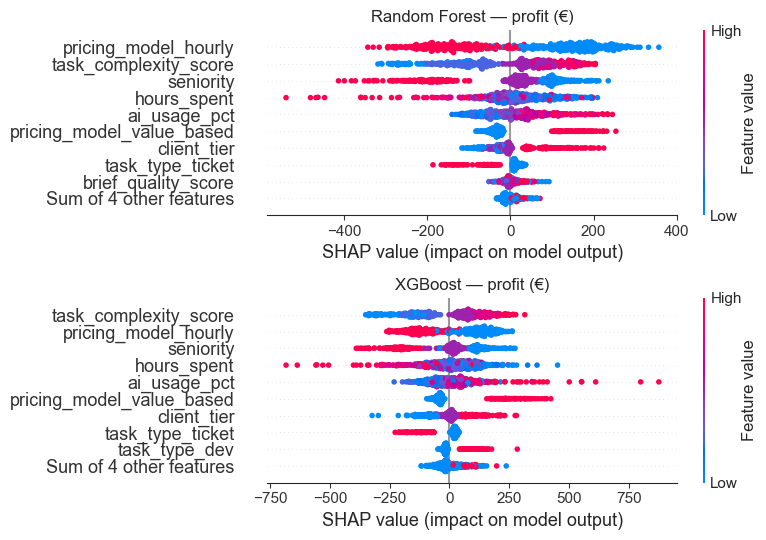

In [33]:
shap_xgb_reg = shap.TreeExplainer(xgb_reg)(X_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=10, show=False)
axes[0].set_title("Random Forest \u2014 profit (\u20ac)", fontsize=12)

plt.sca(axes[1])
shap.plots.beeswarm(shap_xgb_reg, max_display=10, show=False)
axes[1].set_title("XGBoost \u2014 profit (\u20ac)", fontsize=12)

plt.tight_layout()
plt.show()

RF and XGBoost agree on the substance. RF leads slightly in regression (R² ~0.22 vs
0.21) and in classification AUC; both fits are within sampling noise of each other. The
SHAP rankings agree on the top five drivers: `pricing_model_hourly`, seniority, task
complexity, client tier, and AI usage. The narrative does not depend on the algorithm.

## 8. Decision View: Where Losses Concentrate

The classification model (`is_loss = 1` when `profit < 0`) is the operational lens for the decision of where losses concentrate: it flags
which tasks are likely to lose money before they are staffed. The chart below
visualises the **empirical** loss rates that the classifier keys on, grouped by the top
SHAP drivers, so the model output reads as a business decision rather than a score.

For each top driver the test set is split into a "safe" bucket (green) and a "risky"
bucket (red): hourly vs fixed/value-based pricing, senior vs junior/mid, top-25%
hours, top-25% complexity, AI usage at or above the ~30% SHAP threshold, and high vs
low/mid client tier. Within each bucket we compute the share of tasks where
`is_loss = 1`. The result is a six-row table of low-rate, high-rate, gap, and
high-bucket exposure, plotted on a shared y-axis.

- **Left panel (dumbbell).** Two dots per row connected by a grey segment. Green is
  the loss rate at the safe level, red at the risky level. The segment length is the
  gap: longer means the feature flips outcomes more strongly. The dotted vertical
  line is the overall test-set loss rate (~24%) as a no-information baseline.
- **Direction.** Red to the right of green means the high level increases loss risk
  (hourly, long hours, senior). Red to the left means it is protective (AI usage,
  complexity, client tier).
- **Right panel (exposure).** The bar is the share of tasks in the risky bucket. A
  gap only matters if many tasks are exposed to it.

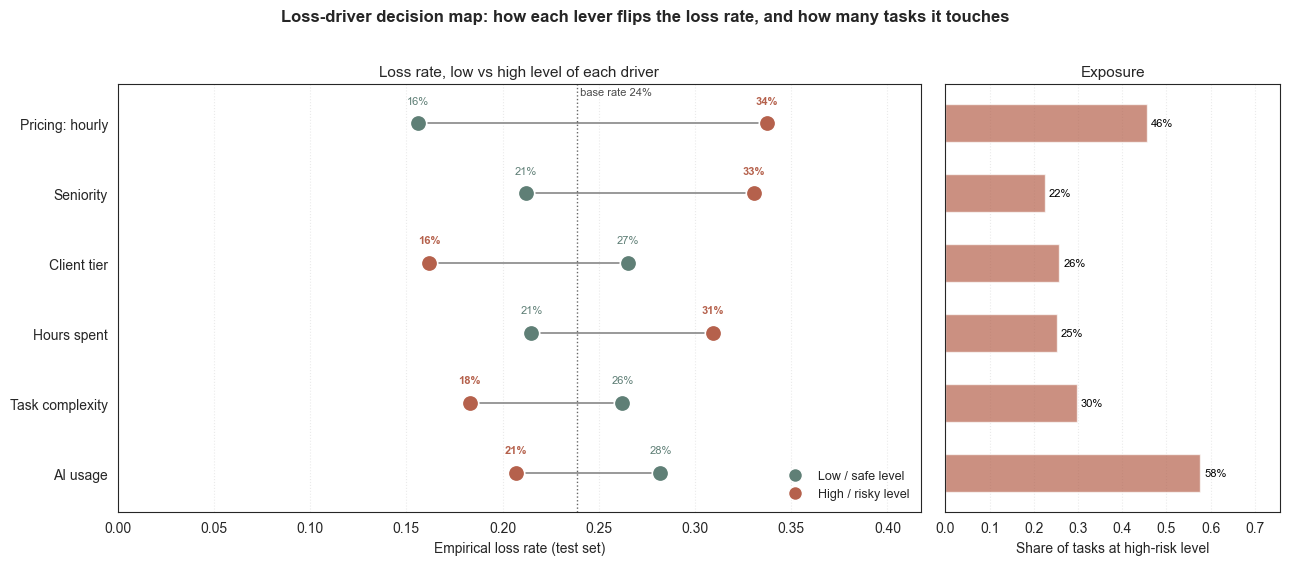

              feature low_rate high_rate  gap high_share
         ai_usage_pct      28%       21%  -8%        58%
task_complexity_score      26%       18%  -8%        30%
          hours_spent      21%       31%   9%        25%
          client_tier      27%       16% -10%        26%
            seniority      21%       33%  12%        22%
 pricing_model_hourly      16%       34%  18%        46%


In [36]:
clf_feats = ["pricing_model_hourly", "seniority", "hours_spent", "ai_usage_pct",
             "task_complexity_score", "client_tier"]
LABELS = {
    "pricing_model_hourly":  ("Pricing: hourly",      "fixed/value", "hourly"),
    "seniority":             ("Seniority",            "junior/mid",  "senior"),
    "hours_spent":           ("Hours spent",          "short",       "long (top 25%)"),
    "ai_usage_pct":          ("AI usage",             f"below {threshold:.0%}", f"at or above {threshold:.0%}"),
    "task_complexity_score": ("Task complexity",      "low/mid",     "high (top 25%)"),
    "client_tier":           ("Client tier",          "low/mid",     "high"),
}

def split_mask(col, X):
    s = X[col]
    if col == "ai_usage_pct":
        return s >= threshold
    if col in {"hours_spent", "task_complexity_score"}:
        return s >= s.quantile(0.75)
    if col == "seniority":
        return s >= 2  # senior
    if col == "client_tier":
        return s >= 2  # high
    return s >= 1      # binary one-hot

base_rate = y_clf_test.mean()
rows = []
for col in clf_feats:
    high = split_mask(col, X_test)
    low  = ~high
    rows.append({
        "feature": col,
        "low_rate":   y_clf_test[low].mean(),
        "high_rate":  y_clf_test[high].mean(),
        "low_share":  low.mean(),
        "high_share": high.mean(),
        "gap":        y_clf_test[high].mean() - y_clf_test[low].mean(),
    })
loss_df = pd.DataFrame(rows).sort_values("gap", key=abs, ascending=True)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [2.4, 1]}, sharey=True,
)

y_pos = np.arange(len(loss_df))
for i, (_, r) in enumerate(loss_df.iterrows()):
    ax1.plot([r.low_rate, r.high_rate], [i, i],
             color="#888", linewidth=1.2, zorder=1)
    ax1.scatter(r.low_rate,  i, s=140, color=ACCENT, zorder=3,
                edgecolor="white", linewidth=1.2)
    ax1.scatter(r.high_rate, i, s=140, color=RISK,   zorder=3,
                edgecolor="white", linewidth=1.2)
    ax1.text(r.low_rate,  i + 0.28, f"{r.low_rate:.0%}",  ha="center",
             fontsize=8, color=ACCENT)
    ax1.text(r.high_rate, i + 0.28, f"{r.high_rate:.0%}", ha="center",
             fontsize=8, color=RISK, fontweight="bold")

ax1.axvline(base_rate, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax1.text(base_rate, len(loss_df) - 0.6, f" base rate {base_rate:.0%}",
         fontsize=8, color="black", alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([LABELS[f][0] for f in loss_df.feature], fontsize=10)
ax1.set_xlim(0, max(loss_df.high_rate.max(), loss_df.low_rate.max()) + 0.08)
ax1.set_xlabel("Empirical loss rate (test set)")
ax1.set_title("Loss rate, low vs high level of each driver", fontsize=11)
ax1.grid(axis="x", linestyle=":", alpha=0.4)

ax2.barh(y_pos, loss_df["high_share"], color=RISK, alpha=0.7, height=0.55)
for i, (_, r) in enumerate(loss_df.iterrows()):
    ax2.text(r.high_share + 0.01, i, f"{r.high_share:.0%}",
             va="center", fontsize=8, color="black")
ax2.set_xlim(0, max(loss_df.high_share) + 0.18)
ax2.set_xlabel("Share of tasks at high-risk level")
ax2.set_title("Exposure", fontsize=11)
ax2.grid(axis="x", linestyle=":", alpha=0.4)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT,
           markersize=10, label="Low / safe level"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=RISK,
           markersize=10, label="High / risky level"),
]
ax1.legend(handles=legend, loc="lower right", frameon=False, fontsize=9)

fig.suptitle(
    "Loss-driver decision map: how each lever flips the loss rate, and how many tasks it touches",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print(loss_df[["feature", "low_rate", "high_rate", "gap", "high_share"]]
      .assign(**{c: lambda d, c=c: d[c].map(lambda v: f"{v:.0%}")
                 for c in ["low_rate", "high_rate", "gap", "high_share"]})
      .to_string(index=False))

## 9. Conclusions


AI compresses hours. Whether that compression becomes margin or leaks to the client is
decided by the contract, not by AI itself. Under fixed and value-based pricing the
saved hours stay with the firm; under hourly pricing they are returned as fewer billed
hours. The OLS interaction (-701 euros, p < 0.001) and the SHAP dependence plots agree:
on hourly tasks AI's contribution is negative at every usage level. Quality is not an
independent channel. Rework matters only through the hours it consumes, and its
financial impact is fully absorbed once `hours_spent` is in the model.

### 9.2 The classification view

The regression sizes the effect; the classifier locates the decision. With balanced
class weights and the pruned feature matrix, the classifier reaches ROC-AUC ~0.75 and
loss recall above 0.55, more than doubling the recall of an unbalanced fit. That makes
it usable as a routing tool: flag a task before it is staffed and the contract or the
assignment can still be changed.

The decision map above ranks drivers by how strongly they flip the empirical loss rate
and by how many tasks they touch. The hierarchy reads as follows:

1. **Pricing model is the largest single lever.** Hourly tasks lose money 34% of the
   time against 16% on fixed and value-based work, an 18-point gap. Hourly is also the
   most prevalent risk bucket (46% of tasks), which makes it the highest-leverage policy
   change.
2. **Seniority is the staffing lever.** Senior contributors raise loss probability from
   21% to 33% (+12 points) when the task is not complex enough to justify their cost.
   Pairing senior staff with low complexity at standard rates is the modal loss
   pattern in the SHAP waterfalls.
3. **Hours and complexity are diagnostic flags.** Long hours push the loss rate up by
   9 points; high complexity pushes it down by 8. The combination of long hours plus
   low complexity is the operational fingerprint of a loss, and the classifier weights
   it heavily.
4. **AI usage is a second-order modifier.** Below the ~30% threshold the loss rate is
   28%; at or above it the rate drops to 19% (-9 points). The protection is real but
   conditional on contracts that let the firm keep the saved hours.

### 9.3 Decision: what to change first

From the classification view three
operational levers stand out, in order of expected return:

- **Renegotiate or retire the hourly model on AI-heavy work.** The contract structure
  converts efficiency gains into client discounts. Even a partial shift to outcome-
  linked or fixed pricing on high-AI workstreams captures the savings the firm is
  currently giving away.
- **Re-route senior staff to high-complexity tasks.** Senior plus low complexity is
  the single most reliable loss signature. Either match seniority to complexity or
  charge a premium that covers the cost.
- **Set an AI adoption floor on fixed and value-based work.** Below ~30% AI usage the
  net effect is a drag because of overhead. Either commit to deeper integration or
  skip AI on that task.

### 9.4 What the data is missing

The four diagnostic questions have answers, but the ceiling on R² (0.21 to 0.22 across
RF and XGBoost) is structural. Three additions would lift it materially:

- The **negotiated rate** for the task. Pricing model is a category; the actual euro
  rate is what determines margin and is unobserved.
- The **loaded cost** of the contributor. Seniority is a three-level proxy; salaries
  and overhead vary continuously inside each level.
- A **client-retention flag**. The strategic value of a task is partly whether the
  client returns; without that signal, single-task profit understates the long horizon.

Tracking **AI tool quality** (which model, which workflow) and aggregating to the
project level would also help, since pricing is negotiated per project, not per task.

### 9.5 Robustness

Findings replicate across OLS, LASSO, Ridge, Random Forest, and XGBoost. Top features
and signs are stable. The two interactions that matter (AI x hourly, AI x seniority)
are significant under HC3 and visible in the tree-based SHAP. The narrative is not
algorithm-specific.